In [1]:
using CSV
using DataFrames
using Statistics
using LsqFit
using Plots

deg = 93

93

In [2]:
dfs = [
    DataFrame(
        CSV.File(
            joinpath("measurement3_2806",
                     "mesure_faible_HeNe_5cm_$(deg)_deg_$(i).csv");
            header=2
        )
    )
    for i in 1:5
]

t = dfs[1][!, "Times/s"]

Vavg = vec(mean(
    hcat([df[!, "Voltage/V"] for df in dfs]...),
    dims=2
))

5000-element Vector{Float64}:
 -9.53125122e-6
 -5.78125074e-6
 -1.64062521e-5
 -1.25000016e-5
 -1.48437519e-5
 -1.468750188e-5
 -1.5625002e-5
 -9.53125122e-6
 -1.531250196e-5
 -1.687500216e-5
 -1.531250196e-5
 -1.859375238e-5
 -1.359375174e-5
  ⋮
  0.00019125002448
  0.00018671877390000002
  0.0001867187739
  0.00019359377478
  0.00018375002352
  0.00018421877358
  0.00018453127362000002
  0.0001945312749
  0.0001828125234
  0.00018390627354
  0.00018562502376
  0.00017859377285999999

In [6]:
using SavitzkyGolay
dVdt = diff(Vavg) ./ diff(t)
dVdt = savitzky_golay(dVdt, 21, 3).y
tmid = (t[1:end-1] .+ t[2:end]) ./ 2

4999-element Vector{Float64}:
 2.0e-12
 6.0e-12
 1.0000000000000001e-11
 1.4e-11
 1.8e-11
 2.2e-11
 2.6e-11
 3.0e-11
 3.4e-11
 3.8e-11
 4.2e-11
 4.5999999999999996e-11
 5.0e-11
 ⋮
 1.995e-8
 1.9954e-8
 1.9958e-8
 1.9961999999999997e-8
 1.9966e-8
 1.997e-8
 1.9973999999999997e-8
 1.9978000000000002e-8
 1.9982e-8
 1.9985999999999998e-8
 1.999e-8
 1.9994e-8

In [7]:
gaussian(t,p) =
    p[1] .* exp.(-((t .- p[2]).^2) ./ (2p[3]^2))

idx0 = argmax(abs.(dVdt))

window = 50

i1 = max(1, idx0-window)
i2 = min(length(dVdt), idx0+window)

tfit = tmid[i1:i2]
yfit = dVdt[i1:i2]

p0 = [
    yfit[argmax(abs.(yfit))],
    tmid[idx0],
    (maximum(tfit)-minimum(tfit))/6,
    mean(yfit)
]

fit = curve_fit(gaussian, tfit, yfit, p0)

p = coef(fit)

println("Arrival time = $(p[2]*1e12) ps")

Arrival time = 4901.025126965825 ps


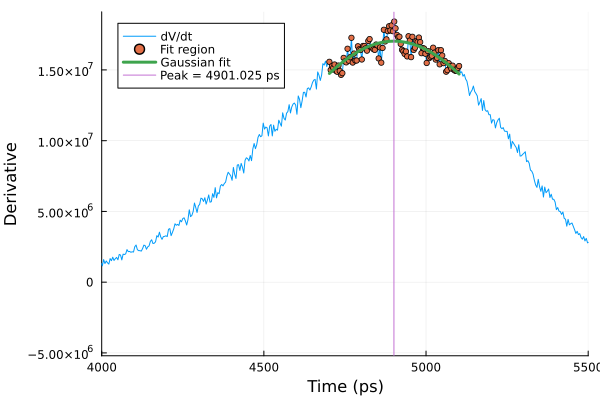

In [9]:
tfine = range(
    minimum(tfit),
    maximum(tfit),
    length=1000
)

plot(
    tmid .* 1e12,
    dVdt,
    label="dV/dt",
    xlabel="Time (ps)",
    ylabel="Derivative",
    lw=1,
    xlims=(4000, 5500)
)

scatter!(
    tfit .* 1e12,
    yfit,
    label="Fit region",
    markersize=3
)

plot!(
    tfine .* 1e12,
    gaussian(tfine,p),
    lw=3,
    label="Gaussian fit"
)

vline!(
    [p[2]*1e12],
    label="Peak = $(round(p[2]*1e12,digits=3)) ps"
)